In [ ]:
import os
import re
import ast
import pandas
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib import cm
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go


In [8]:
# LOAD TABLES /////////////////////////////////////////////

# Results paht
main_path ='C:\\Users\\viviamsb\\OneDrive - NTNU\\PhD Folder\\Pipeline\\DrugLogics_pipeline_modules\\run_all\\run_oncologics_neko_oncologics'

# Supplementary files path
supplementary_files_path = main_path + '\\hsa\\20251013\\supplementary_files\\'

# PREDICTIONS
predictions_file_path = supplementary_files_path + 'predictions_full_df.csv'

# HSA
hsa_screen = 'C:\\Users\\viviamsb\\OneDrive - NTNU\\PhD Folder\\Pipeline\\DrugLogics_pipeline_modules\\module_scripts\\input\\oncologics_dataset\\lab_screen_hsa.csv'
hsa_screen_df = pandas.read_csv(hsa_screen, sep=',', header=0,)
hsa_file_path = 'C:\\Users\\viviamsb\\OneDrive - NTNU\\PhD Folder\\Pipeline\\DrugLogics_pipeline_modules\\run_all\\run_oncologics_neko_oncologics\\hsa\\20250423\\supplementary_files\\hsa_metrics_cells.csv'
hsa_results = pandas.read_csv(hsa_file_path, sep=',', header=0, index_col=0)
# BLISS
bliss_file_path = 'C:\\Users\\viviamsb\\OneDrive - NTNU\\PhD Folder\\Pipeline\\DrugLogics_pipeline_modules\\run_all\\run_oncologics_neko_oncologics\\bliss\\20250423\\supplementary_files\\bliss_metrics_cells.csv'
bliss_results = pandas.read_csv(bliss_file_path, sep=',', header=0, index_col=0)

## PREDICTIONS

In [9]:
predictions_full = pandas.read_csv(predictions_file_path)


info_columns = ['PERTURBATION', 'PD_A', 'PD_B', 'DRUG_NAME_A', 'DRUG_NAME_B','NODE_TARGETS_A', 'NODE_TARGETS_B', 'DRUG_COMBINATION','inhibitor_group_A', 'inhibitor_group_B', 'inhibitor_combination']
cell_line_columns = ['C2BBE1', 'CAR1', 'CL11', 'HT115', 'LS123', 'NCIH508', 'NCIH716', 'NCIH747', 'SNU81', 'SW1116', 'SW1417', 'SW1463', 'SW620','SW837', 'SW948', 'T84']

# Melt cell lines into synergy column
predictions_melted = predictions_full.melt(
    id_vars=info_columns,
    value_vars=cell_line_columns,
    var_name='cell_line',
    value_name='synergy'
)

# Mechanism of action groups
moa_groups = {
    'Apoptosis': ['BCL2i', 'BCL2L1i'],
    'Cell Cycle': ['CyclinDi', ],
    'DNA Damage': ['PARPi', 'CHK1i', 'Wee1i', 'MK2i'],
    'PI3K/AKT/MTOR': ['PIK3i', 'PIK3mTORi', 'AKTi', 'S6Ki', 'BRAFi', 'PIK3mTORatmi', 'mTORi'],
    'MAPK': ['MEKi', 'ERKi', 'KRASi'],
    'RTK': ['IGF1Ri', 'EGFRi', 'EGFRbRAFi'],
    'WNT': ['GSK3Bi']
}

# Add moa_group column
def get_moa_group(inhibitor_group):
    for group, inhibitors in moa_groups.items():
        if inhibitor_group in inhibitors:
            return group
    return 'Other'
predictions_melted['moa_group_A'] = predictions_melted['inhibitor_group_A'].apply(get_moa_group)
predictions_melted['moa_group_B'] = predictions_melted['inhibitor_group_B'].apply(get_moa_group)
print(predictions_melted.columns)

# Multiply synergy by -1 to have synergistic combinations with higher values
predictions_melted['synergy'] = -1 * predictions_melted['synergy']

Index(['PERTURBATION', 'PD_A', 'PD_B', 'DRUG_NAME_A', 'DRUG_NAME_B',
       'NODE_TARGETS_A', 'NODE_TARGETS_B', 'DRUG_COMBINATION',
       'inhibitor_group_A', 'inhibitor_group_B', 'inhibitor_combination',
       'cell_line', 'synergy', 'moa_group_A', 'moa_group_B'],
      dtype='object')


C:\Users\viviamsb\AppData\Local\Temp\ipykernel_27760\895617000.py:92: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

C:\Users\viviamsb\AppData\Local\Temp\ipykernel_27760\895617000.py:93: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

C:\Users\viviamsb\AppData\Local\Temp\ipykernel_27760\895617000.py:94: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



Non-NaN cells (should be nC2): 210


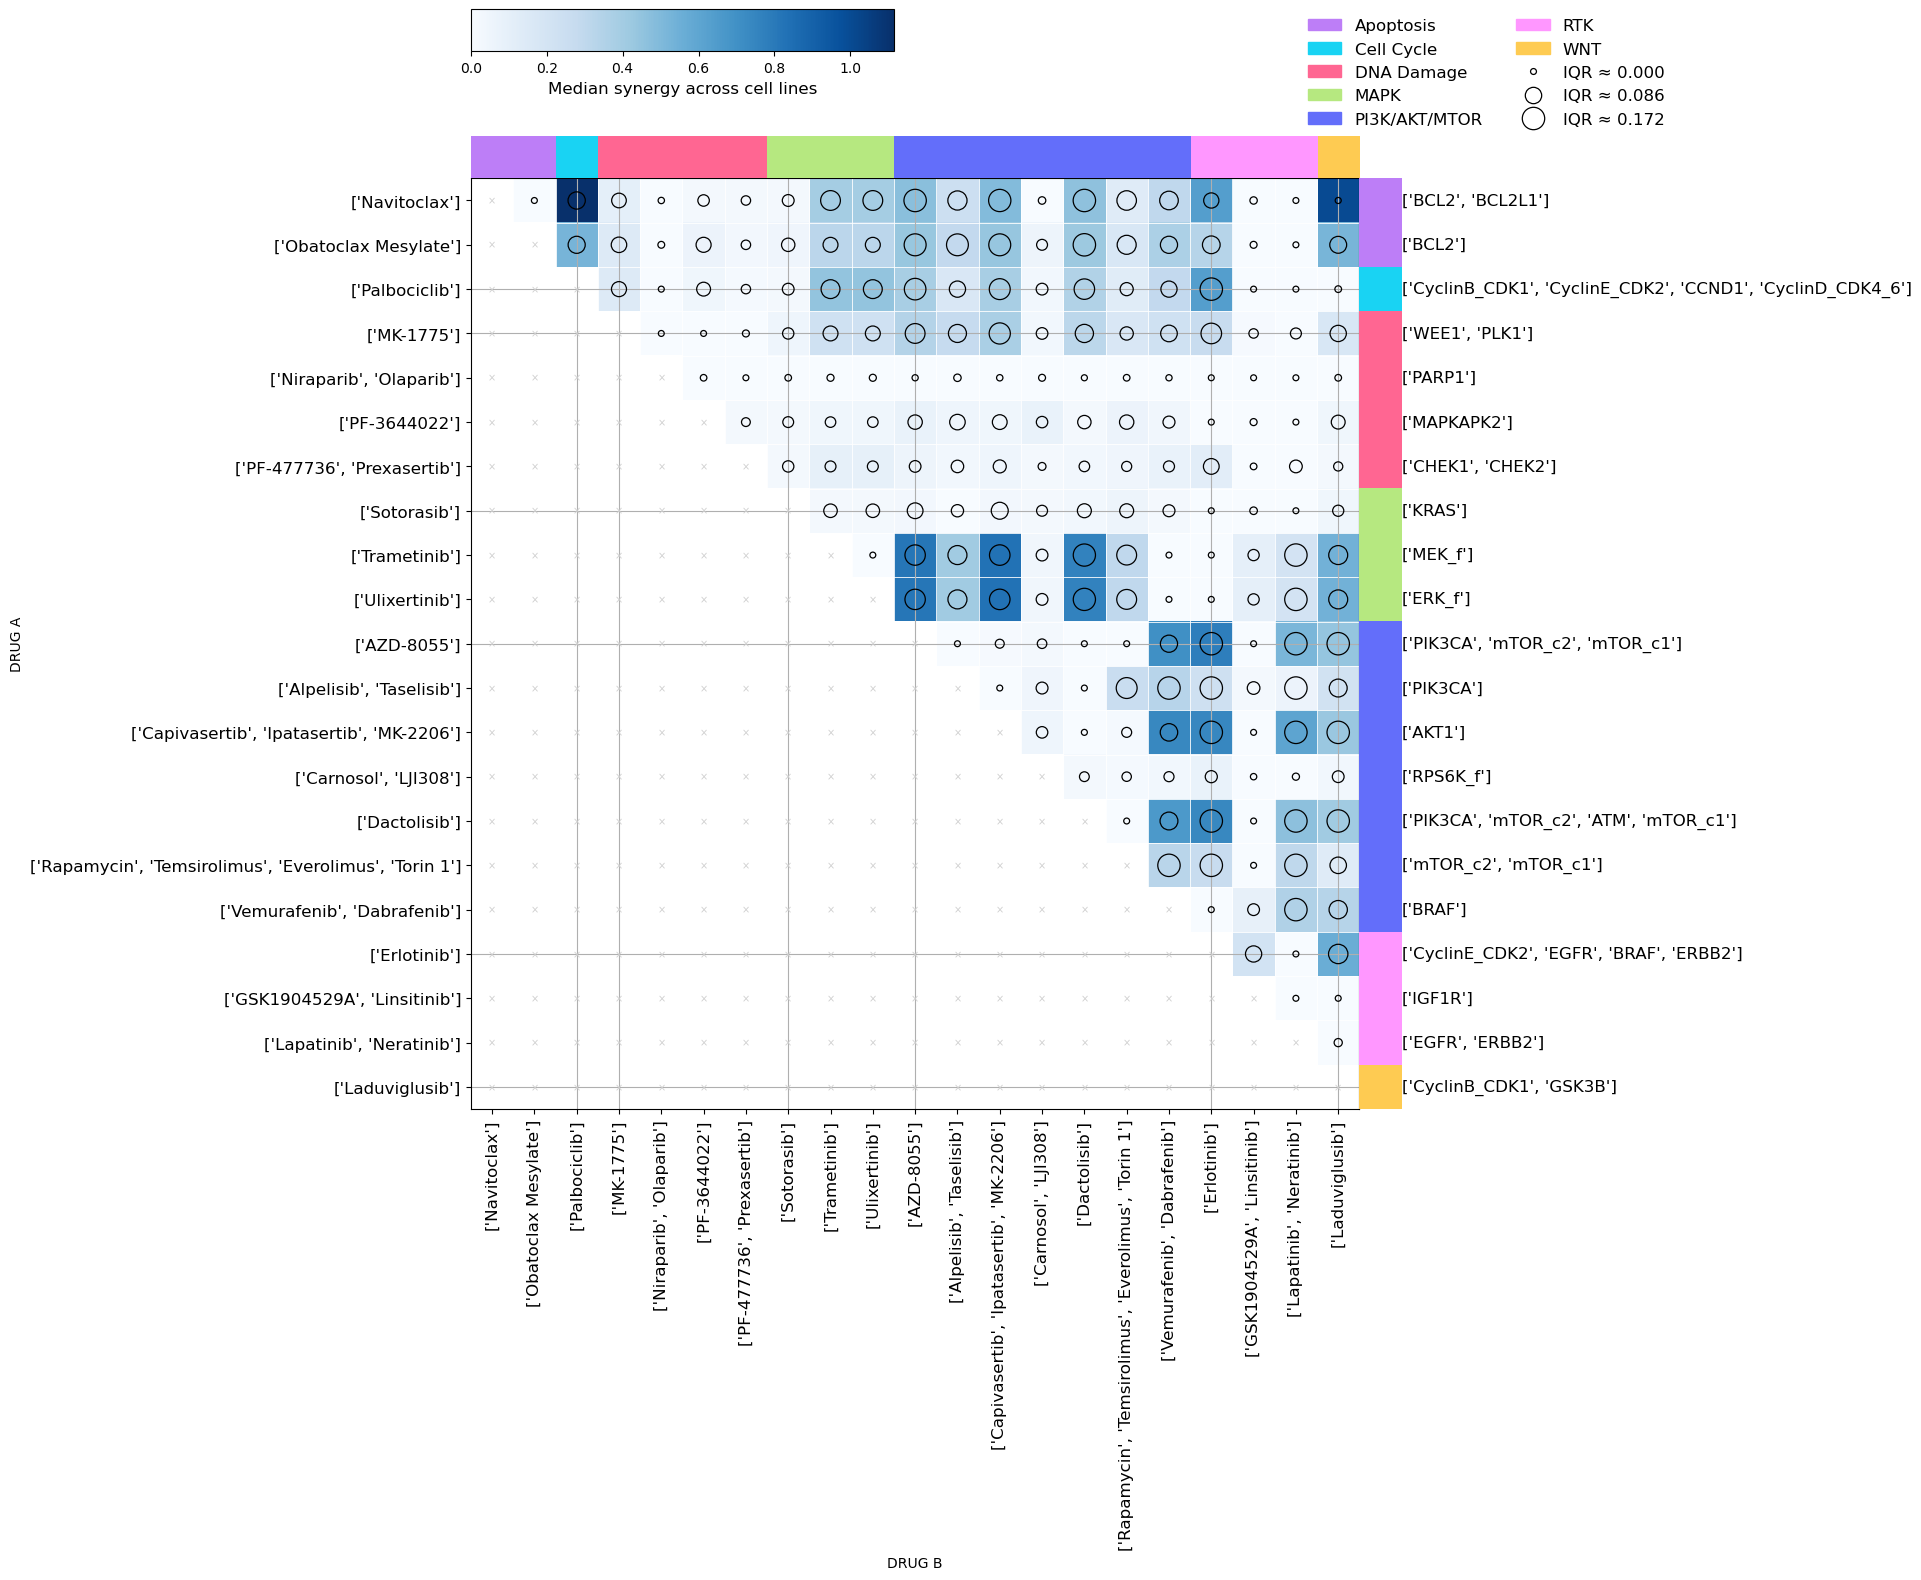

In [11]:
import pathlib

# ================================
# Heatmap: median (Blues) + IQR dots
# Mechanism bands (discrete) + NODE_TARGET labels (right)
# Works with WIDE or MELTED input
# ================================

# ---------- 0) CONFIG ----------
# (a) Si ya tienes un DataFrame en memoria, asigna df = tu_dataframe
# (b) O lee desde CSV:
# df = pd.read_csv("predictions_full_df.csv")     # ancho
df = predictions_melted.copy()                  # melted

# Map: inhibitor_group -> MOA (tu mapeo)
MOA_GROUPS = {
    'Apoptosis': ['BCL2i', 'BCL2L1i'],
    'Cell Cycle': ['CyclinDi'],
    'DNA Damage': ['PARPi', 'CHK1i', 'Wee1i', 'MK2i'],
    'PI3K/AKT/MTOR': ['PIK3i', 'PIK3mTORi', 'AKTi', 'S6Ki', 'BRAFi', 'PIK3mTORatmi', 'mTORi'],
    'MAPK': ['MEKi', 'ERKi', 'KRASi'],
    'RTK': ['IGF1Ri', 'EGFRi', 'EGFRbRAFi'],
    'WNT': ['GSK3Bi']
}
REV_MAP = {g:m for m,gs in MOA_GROUPS.items() for g in gs}

# ---------- 1) HELPERS ----------
def compute_pair_stats_from_wide(df_w):
    """df_w ancho: columnas de cell lines + meta:
       ['PD_A','PD_B','DRUG_NAME_A','DRUG_NAME_B',
        'NODE_TARGETS_A','NODE_TARGETS_B',
        'inhibitor_group_A','inhibitor_group_B', ...]"""
    meta_cols = {"PERTURBATION","PD_A","PD_B","DRUG_NAME_A","DRUG_NAME_B",
                 "NODE_TARGETS_A","NODE_TARGETS_B","DRUG_COMBINATION",
                 "inhibitor_group_A","inhibitor_group_B","inhibitor_combination"}
    cell_cols = [c for c in df_w.columns if c not in meta_cols]
    vals = df_w[cell_cols].apply(pandas.to_numeric, errors="coerce")
    med = vals.median(axis=1, skipna=True)
    q3  = vals.quantile(0.75, axis=1, interpolation="linear")
    q1  = vals.quantile(0.25, axis=1, interpolation="linear")
    iqr = q3 - q1
    n   = vals.notna().sum(axis=1)
    pair = df_w[["PD_A","PD_B"]].astype(str).copy()
    pair["median_synergy"] = med
    pair["iqr_synergy"]    = iqr
    pair["n"]              = n
    # Per-drug meta
    metaA = df_w[["PD_A","DRUG_NAME_A","inhibitor_group_A","NODE_TARGETS_A"]].drop_duplicates()
    metaA.columns = ["PD","NAME","INHIB","NODE"]
    metaB = df_w[["PD_B","DRUG_NAME_B","inhibitor_group_B","NODE_TARGETS_B"]].drop_duplicates()
    metaB.columns = ["PD","NAME","INHIB","NODE"]
    drug_meta = pandas.concat([metaA, metaB], ignore_index=True).drop_duplicates("PD", keep="first")
    return pair, drug_meta

def compute_pair_stats_from_melted(df_m):
    """df_m long/melted con columnas:
       ['PD_A','PD_B','DRUG_NAME_A','DRUG_NAME_B','cell_line','synergy',
        'NODE_TARGETS_A','NODE_TARGETS_B','inhibitor_group_A','inhibitor_group_B',
        (opcional) 'moa_group_A','moa_group_B']"""
    pair = (df_m.groupby(["PD_A","PD_B"], as_index=False)
              .agg(median_synergy=("synergy","median"),
                   iqr_synergy=("synergy",
                               lambda x: np.nanpercentile(x,75)-np.nanpercentile(x,25)),
                   n=("synergy","size"))
              .astype({"PD_A":str,"PD_B":str}))
    metaA = df_m[["PD_A","DRUG_NAME_A","inhibitor_group_A","NODE_TARGETS_A"]].drop_duplicates()
    metaA.columns = ["PD","NAME","INHIB","NODE"]
    metaB = df_m[["PD_B","DRUG_NAME_B","inhibitor_group_B","NODE_TARGETS_B"]].drop_duplicates()
    metaB.columns = ["PD","NAME","INHIB","NODE"]
    drug_meta = pandas.concat([metaA, metaB], ignore_index=True).drop_duplicates("PD", keep="first")
    return pair, drug_meta

def make_order_and_pivot(pair, drug_meta):
    # Map MOA from inhibitor group (si ya tienes moa_group_* puedes fusionarlas aquí)
    drug_meta = drug_meta.copy()
    drug_meta["MOA"] = drug_meta["INHIB"].map(REV_MAP).fillna("Unlabeled")
    # Orden común para ambos ejes: MOA → NAME → PD
    ordered_PD = (drug_meta.sort_values(["MOA","NAME","PD"])["PD"].astype(str).tolist())
    rank = {pdid:i for i,pdid in enumerate(ordered_PD)}
    # Reorientar cada par por rank para que quede en el mismo triángulo
    def order_pair(a,b):
        return (a,b) if rank[a] <= rank[b] else (b,a)
    op = pair.apply(lambda r: order_pair(r["PD_A"], r["PD_B"]), axis=1, result_type="expand")
    pair["PD_A_ord"], pair["PD_B_ord"] = op[0], op[1]
    pair2 = (pair.groupby(["PD_A_ord","PD_B_ord"], as_index=False)
                .agg(median_synergy=("median_synergy","median"),
                     iqr_synergy=("iqr_synergy","median"),
                     n=("n","max")))
    # Pivot a matrices cuadradas con MISMO orden en filas/columnas
    pair2["PD_A_ord"] = pandas.Categorical(pair2["PD_A_ord"], ordered_PD, ordered=True)
    pair2["PD_B_ord"] = pandas.Categorical(pair2["PD_B_ord"], ordered_PD, ordered=True)
    M_med = pair2.pivot_table(index="PD_A_ord", columns="PD_B_ord", values="median_synergy").reindex(index=ordered_PD, columns=ordered_PD)
    M_iqr = pair2.pivot_table(index="PD_A_ord", columns="PD_B_ord", values="iqr_synergy").reindex(index=ordered_PD, columns=ordered_PD)
    M_n   = pair2.pivot_table(index="PD_A_ord", columns="PD_B_ord", values="n").reindex(index=ordered_PD, columns=ordered_PD)
    # Diccionarios para labels
    PD2name = dict(zip(drug_meta["PD"].astype(str), drug_meta["NAME"]))
    PD2node = dict(zip(drug_meta["PD"].astype(str), drug_meta["NODE"]))
    PD2moa  = dict(zip(drug_meta["PD"].astype(str), drug_meta["MOA"]))
    return ordered_PD, M_med, M_iqr, M_n, PD2name, PD2node, PD2moa

def plot_figure(ordered_PD, M_med, M_iqr, M_n, PD2name, PD2node, PD2moa,
                figsize=(12.5,12.5), outfile=None, dpi=300):
    # Bandas discretas (MOA)
    moa_axis = [PD2moa.get(p,"Unlabeled") for p in ordered_PD]
    moa_cats = list(dict.fromkeys(moa_axis))
    base = plt.get_cmap("tab10")
    # Manual color map for mechanism groups
    moa_colors = {
        'Apoptosis':        "#bd7ef7",
        'Cell Cycle':       "#19D3F3",
        'DNA Damage':       "#FF6692",
        'PI3K/AKT/MTOR':    "#636EFA",
        'MAPK':             "#B6E880",
        'RTK':              "#FF97FF",
        'WNT':              "#FECB52",
        'Unlabeled':        '#d9d9d9'
    }
    colors = [moa_colors.get(m, moa_colors['Unlabeled']) for m in moa_cats]
    cmap_mech = ListedColormap(colors)
    norm_mech = BoundaryNorm(np.arange(len(moa_cats)+1), cmap_mech.N)
    moa2idx = {m:i for i,m in enumerate(moa_cats)}
    band_top   = np.array([[moa2idx[m] for m in moa_axis]])
    band_right = band_top.T
    legend_handles = [Patch(color=colors[i], label=lab) for i,lab in enumerate(moa_cats)]

    # Labels
    xlabels = [PD2name.get(p,p) for p in ordered_PD]
    ylabels = xlabels
    node_labels = [PD2node.get(p,"") for p in ordered_PD]

    # Layout
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(26,26, left=0.08, right=0.96, top=0.96, bottom=0.08, wspace=0.0, hspace=0.0)
    ax = fig.add_subplot(gs[4:26, 0:21])                    # heatmap
    ax_top_band = fig.add_subplot(gs[3:4, 0:21], sharex=ax) # MOA band (top)
    ax_right_band = fig.add_subplot(gs[4:26, 21:22], sharey=ax)  # MOA band (right)
    ax_right_labels = fig.add_subplot(gs[4:26, 22:26], sharey=ax) # NODE_TARGET labels (right side)
    ax_cbar = fig.add_subplot(gs[0:1, 0:10])                 # colorbar top
    ax_title = fig.add_subplot(gs[1:2, 0:21]); ax_title.axis("off")

    # Heatmap (Blues continuo)
    im = ax.imshow(M_med.values, aspect="auto", interpolation="nearest", cmap="Blues")
    im.cmap.set_bad("white")  # triángulo no usado

    # Ticks
    ax.set_xticks(range(len(ordered_PD))); ax.set_yticks(range(len(ordered_PD)))
    ax.set_xticklabels(xlabels, rotation=90, fontsize=12)
    ax.set_yticklabels(ylabels, fontsize=12)
    ax.set_xticks(np.arange(-.5,len(ordered_PD),1), minor=True)
    ax.set_yticks(np.arange(-.5,len(ordered_PD),1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.6)
    ax.tick_params(which="minor", length=0)

    # Círculos por IQR
    valid = ~np.isnan(M_med.values)
    r_idx, c_idx = np.where(valid)
    iq_vals = M_iqr.values[valid]
    n_vals  = M_n.values[valid]
    p10, p90 = (np.nanpercentile(iq_vals, [10,90]) if np.isfinite(iq_vals).any() else (0,1))
    def size_from_iqr(v, smin=18, smax=260):
        if np.isnan(v): return 0.0
        v = np.clip(v, p10, p90); t = 0 if p90==p10 else (v-p10)/(p90-p10)
        return smin + t*(smax-smin)
    sizes = [size_from_iqr(v) if (not np.isnan(v) and n>=2) else 12 for v,n in zip(iq_vals, n_vals)]
    ax.scatter(c_idx, r_idx, s=sizes, facecolors="none", edgecolors="black", linewidths=0.9, zorder=3)

    # Marca suave en celdas sin usar (orientación opuesta)
    for i in range(M_med.shape[0]):
        for j in range(M_med.shape[1]):
            if np.isnan(M_med.values[i,j]):
                ax.text(j, i, "×", ha="center", va="center", fontsize=7, color="#cfcfcf")

    # Bandas + labels de NODE_TARGET a la derecha
    ax_top_band.imshow(band_top, aspect="auto", cmap=cmap_mech, norm=norm_mech); ax_top_band.axis("off")
    ax_right_band.imshow(band_right, aspect="auto", cmap=cmap_mech, norm=norm_mech); ax_right_band.axis("off")

    # NODE_TARGET labels on the right (smaller font) + MOA separators
    ax_right_labels.set_xlim(0,1); ax_right_labels.set_ylim(ax.get_ylim()); ax_right_labels.axis("off")
    for i, lab in enumerate(node_labels):
        ax_right_labels.text(0, i, str(lab), va="center", fontsize=12)

     # Draw thin separator lines where MOA changes (top and right)
     # compute row breaks
    row_moas = moa_axis
    breaks = [i for i in range(1, len(row_moas)) if row_moas[i] != row_moas[i-1]]
    for b in breaks:
        ax.hlines(b, -0.5, len(ordered_PD)-0.5, colors="#afafaf", linewidth=0.8)
        ax.vlines(b, -0.5, len(ordered_PD)-0.5, colors="#afafaf", linewidth=0.8)

    # Colorbar arriba
    cbar = fig.colorbar(im, cax=ax_cbar, orientation="horizontal")
    cbar.set_label("Median synergy across cell lines", fontsize=12)

    # Título + leyenda de mecanismos
    # ax_title.text(0, 1, "Targeted mechanism or pathway", fontsize=12, va="center")
    # Mover la leyenda a la derecha del grid (columnas 22:26)
    ax_legend = fig.add_subplot(gs[1:2, 22:30])
    ax_legend.axis("off")
    ax_legend.legend(handles=legend_handles, loc="center",
                     ncol=2, frameon=False, fontsize=12)

    # Add legend for IQR circles

    # Representative IQR values (p10, mid, p90) and corresponding marker sizes
    iqr_vals_legend = [p10, (p10 + p90) / 2.0, p90]
    sizes_legend = [size_from_iqr(v) for v in iqr_vals_legend]
    # scatter 's' is area in points^2; Line2D markersize expects diameter in points
    markersizes = [np.sqrt(max(1.0, s)) for s in sizes_legend]

    circle_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='none', markeredgecolor='black',
               markeredgewidth=0.9, markersize=ms)
        for ms in markersizes
    ]
    circle_labels = [f"IQR ≈ {v:.3f}" for v in iqr_vals_legend]

    # Combine MOA legend handles and circle handles into one legend block
    combined_handles = legend_handles + circle_handles
    combined_labels = moa_cats + circle_labels

    ax_legend.axis("off")
    ax_legend.legend(handles=combined_handles, labels=combined_labels,
                     loc="center", ncol=2, frameon=False, fontsize=12)
    # Ejes
    ax.set_xlabel("DRUG B")
    ax.set_ylabel("DRUG A")

    if outfile:
        fig.savefig(outfile, dpi=dpi, bbox_inches="tight")
    plt.show()

# ---------- 2) RUN ----------
def build_and_plot(df, outfile=None):
    # Detectar formato
    cols = set(df.columns.str.lower())
    is_melted = {"cell_line","synergy"}.issubset(cols)
    if is_melted:
        pair, drug_meta = compute_pair_stats_from_melted(df)
    else:
        pair, drug_meta = compute_pair_stats_from_wide(df)

    ordered_PD, M_med, M_iqr, M_n, PD2name, PD2node, PD2moa = make_order_and_pivot(pair, drug_meta)
    print("Non-NaN cells (should be nC2):", int(np.sum(~np.isnan(M_med.values))))

    # Ensure output directory exists if an outfile was provided
    outpath = None
    if outfile:
        outpath = pathlib.Path(outfile)
        if not outpath.parent.exists():
            outpath.parent.mkdir(parents=True, exist_ok=True)

    plot_figure(ordered_PD, M_med, M_iqr, M_n, PD2name, PD2node, PD2moa,
                figsize=(12.5,12.5), outfile=str(outpath) if outpath else None, dpi=300)

# Ejemplo de uso:
# df = pandas.read_csv(predictions_file_path)   # o usa predictions_melted
build_and_plot(df, outfile=supplementary_files_path + 'predictions_fullscreen.png')


C:\Users\viviamsb\AppData\Local\Temp\ipykernel_27760\2419765739.py:43: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\viviamsb\AppData\Local\Temp\ipykernel_27760\2419765739.py:124: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



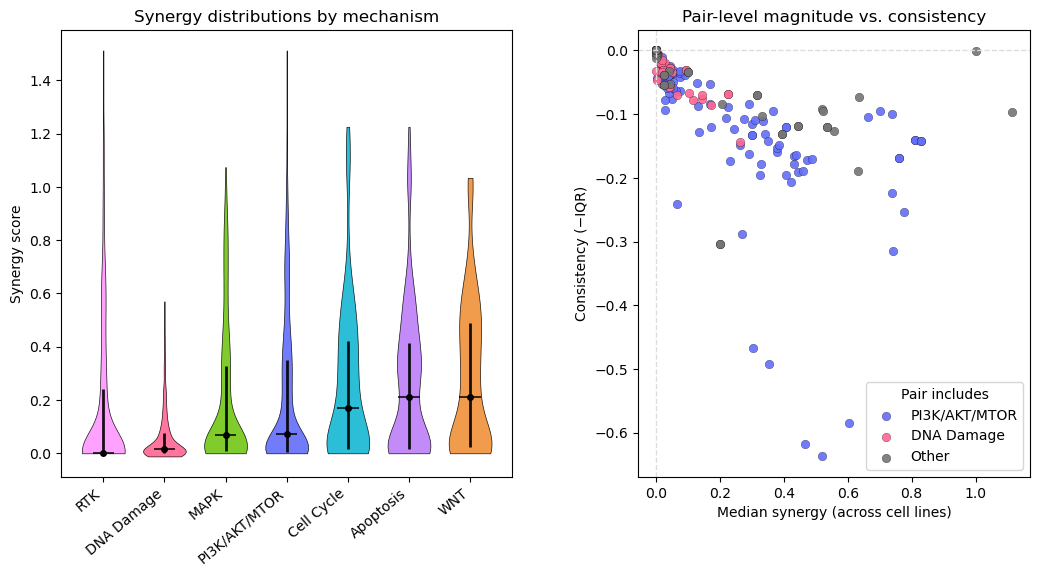

In [12]:
# ===============================================
# Callouts figure (Panels A & B) — MECHANISMS
# Panel A: distributions by mechanism (violins)
# Panel B: pair-level magnitude vs consistency
# Color scheme: user-provided moa_colors
# Exports: PNG + SVG
# ===============================================

# ---------- Input ----------
# df = pandas.read_csv(predictions_file_path)
df = predictions_melted.copy()

moa_colors = {
        'Apoptosis':        "#bd7ef7",
        'Cell Cycle':       "#16B7D3",
        'DNA Damage':       "#FF6692",
        'PI3K/AKT/MTOR':    "#636EFA",
        'MAPK':             "#71C715",
        'RTK':              "#FF97FF",
        'WNT':              "#F09138",
        'Unlabeled':        "#757575"
    }
# Legend order
MOA_ORDER = ["PI3K/AKT/MTOR","DNA Damage","MAPK","RTK","Cell Cycle","Apoptosis","WNT","Unlabeled"]

# =========================
# Panel A — distributions
# =========================
# Duplicate each (pair, cell line) observation for both mechanisms in the pair
A_part = df[["synergy","moa_group_A"]].rename(columns={"moa_group_A":"mechanism"}).copy()
B_part = df[["synergy","moa_group_B"]].rename(columns={"moa_group_B":"mechanism"}).copy()
stacked = pandas.concat([A_part, B_part], ignore_index=True).dropna(subset=["synergy"])

# Order mechanisms by their median synergy (ascending => stronger left)
order_mech = (stacked.groupby("mechanism")["synergy"]
              .median().sort_values(ascending=True).index.tolist())
# keep MOA_ORDER if you prefer fixed order:
# order_mech = [m for m in MOA_ORDER if m in stacked["mechanism"].unique()]

stacked["mechanism"] = pandas.Categorical(stacked["mechanism"], order_mech, ordered=True)

# Summary for median/IQR overlays
summary_A = (stacked.groupby("mechanism")["synergy"]
             .agg(median="median",
                  q1=lambda x: np.nanpercentile(x,25),
                  q3=lambda x: np.nanpercentile(x,75))).reset_index()

# =========================
# Panel B — pair-level map
# =========================
# Aggregate per unique unordered pair (by PD IDs)
pair_stats = (df.groupby(["PD_A","PD_B"], as_index=False)
                .agg(median=("synergy","median"),
                     iqr=("synergy",
                          lambda x: np.nanpercentile(x,75)-np.nanpercentile(x,25)),
                     n=("synergy","size"),
                     DRUG_NAME_A=("DRUG_NAME_A","first"),
                     DRUG_NAME_B=("DRUG_NAME_B","first"),
                     moa_A=("moa_group_A","first"),
                     moa_B=("moa_group_B","first")))

# Labels for highlighting mechanisms in the pair
def fam_label(r):
    if r["moa_A"]=="PI3K/AKT/MTOR" or r["moa_B"]=="PI3K/AKT/MTOR":
        return "PI3K/AKT/MTOR"
    if r["moa_A"]=="DNA Damage" or r["moa_B"]=="DNA Damage":
        return "DNA Damage"
    return "Other"

pair_stats["family"] = pair_stats.apply(fam_label, axis=1)
pair_stats["consistency"] = -pair_stats["iqr"]

family_order = ["PI3K/AKT/MTOR","DNA Damage","Other"]
family_colors = {
    "PI3K/AKT/MTOR": moa_colors["PI3K/AKT/MTOR"],
    "DNA Damage":    moa_colors["DNA Damage"],
    "Other":         moa_colors["Unlabeled"]
}

# =========================
# Plot
# =========================
fig = plt.figure(figsize=(12.5, 5.8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.15, 1.0], wspace=0.30)

# Panel A: violin by mechanism
ax1 = fig.add_subplot(gs[0,0])
data = [stacked.loc[stacked["mechanism"]==m, "synergy"].values for m in order_mech]
vp = ax1.violinplot(data, showmedians=True, showextrema=False, widths=0.7, )

# Color each violin with moa_colors
for body, mech in zip(vp['bodies'], order_mech):
    body.set_facecolor(moa_colors.get(mech, "#cccccc"))
    body.set_edgecolor("black")
    body.set_alpha(0.9)
    body.set_linewidth(0.5)
if 'cmedians' in vp:
    vp['cmedians'].set_color("black"); vp['cmedians'].set_linewidth(1.1)

# IQR whiskers + median point
for i, mech in enumerate(order_mech, start=1):
    row = summary_A.loc[summary_A["mechanism"]==mech].iloc[0]
    ax1.vlines(i, row["q1"], row["q3"], color="black", lw=2, alpha=0.9)
    ax1.scatter([i], [row["median"]], color="black", s=16, zorder=3)

ax1.set_xticks(range(1, len(order_mech)+1))
ax1.set_xticklabels(order_mech, rotation=40, ha="right")
ax1.set_ylabel("Synergy score")
ax1.set_title("Synergy distributions by mechanism")

# Panel B: median vs. consistency (−IQR)
ax2 = fig.add_subplot(gs[0,1])
for fam in family_order:
    sub = pair_stats[pair_stats["family"]==fam]
    ax2.scatter(sub["median"], sub["consistency"], s=38, alpha=0.9,
                color=family_colors[fam], edgecolors='k', linewidths=0.2, label=fam)
ax2.axvline(0, color="#dddddd", linestyle="--", lw=1)   # reference for median
ax2.axhline(0, color="#dddddd", linestyle="--", lw=1)   # reference for consistency
ax2.set_xlabel("Median synergy (across cell lines)")
ax2.set_ylabel("Consistency (−IQR)")
ax2.set_title("Pair-level magnitude vs. consistency")
ax2.legend(title="Pair includes", frameon=True, ncol=1, loc="lower right")

plt.tight_layout()

# ---------- Export ----------
# plt.savefig("callouts_panels_AB.png", dpi=400, bbox_inches="tight")
# plt.savefig("callouts_panels_AB.svg", bbox_inches="tight")
plt.show()



In [13]:
def extract_drug_list(val):
    """Convert a value to a list of drug names."""
    if pandas.isna(val):
        return []
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            # Try to parse stringified list
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [str(x) for x in parsed]
            else:
                return [str(parsed)]
        except Exception:
            # Not a list, just return as single-element list
            return [val]
    return [str(val)]

# Create PD_dict for PD_iD to DRUG_NAME mapping
PD_dict = {}
for index, row in predictions_full.iterrows():
    PD_dict[row['PD_A']] = row['DRUG_NAME_A']
    PD_dict[row['PD_B']] = row['DRUG_NAME_B']

# Build reverse maps from PD_dict values (which may be lists or stringified lists)
exact_map = {}
lower_map = {}
norm_map = {}

for pdid, val in PD_dict.items():
    names = extract_drug_list(val)
    for name in names:
        if not name:
            continue
        exact_map[name] = str(pdid)
        lower_map[name.lower()] = str(pdid)
        def normalize_name(name):
            """Normalize drug names for robust matching."""
            if not isinstance(name, str):
                name = str(name)
            # Remove common punctuation, spaces, and lowercase
            name = name.lower()
            name = re.sub(r'[\s\-\(\)\[\],.;:_/\\\']', '', name)
            name = name.replace('&', 'and')
            return name.strip()
        n = normalize_name(name)
        if n:
            norm_map.setdefault(n, str(pdid))

# Find two drug-like columns in hsa_screen_df (robust fallback)
drug_like = [c for c in hsa_screen_df.columns if any(k in c.lower() for k in ('drug','compound','name'))]
if len(drug_like) >= 2:
    col_a, col_b = drug_like[0], drug_like[1]
else:
    cols = list(hsa_screen_df.columns)
    col_a = cols[0] if cols else None
    col_b = cols[1] if len(cols) > 1 else col_a

def find_pdid_from_cell(val):
    if pandas.isna(val):
        return pandas.NA
    names = extract_drug_list(val)
    # exact
    for name in names:
        if name in exact_map:
            return exact_map[name]
    # case-insensitive
    for name in names:
        low = name.lower()
        if low in lower_map:
            return lower_map[low]
    # normalized exact
    for name in names:
        n = normalize_name(name)
        if n in norm_map:
            return norm_map[n]
    # normalized partial match
    for name in names:
        n = normalize_name(name)
        if not n:
            continue
        for k_norm, pdid in norm_map.items():
            if n in k_norm or k_norm in n:
                return pdid
    # fallback fuzzy: substring against exact_map keys (lower)
    for name in names:
        low = name.lower()
        for k, pdid in lower_map.items():
            if low in k or k in low:
                return pdid
    return pandas.NA

# Add PD id columns to hsa_screen_df (use names PD_A_match / PD_B_match to avoid overwriting)
if col_a is not None:
    hsa_screen_df['PD_A'] = hsa_screen_df[col_a].map(find_pdid_from_cell)
if col_b is not None:
    hsa_screen_df['PD_B'] = hsa_screen_df[col_b].map(find_pdid_from_cell)


hsa_screen_df.columns

Index(['drug1', 'drug2', 'target1', 'target2', 'CAR1', 'LS123', 'T84',
       'NCI-H508', 'NCI-H716', 'NCI-H747', 'SNU-81', 'SW620', 'SW837', 'SW948',
       'SW1417', 'SW1463', 'C2BBe1', 'CL-11', 'HT-115', 'SW1116', 'PD_A',
       'PD_B'],
      dtype='object')

In [14]:
# Extract PD combinations
PD_combi = []
for index, row in hsa_screen_df.iterrows():
    pd_a = row['PD_A']
    pd_b = row['PD_B']
    if pandas.isna(pd_a) or pandas.isna(pd_b):
        continue
    else:
        # Order PDs to have consistent representation
        pd_pair = sorted([str(pd_a), str(pd_b)])
        PD_combi.append(f"{pd_pair[0]} | {pd_pair[1]}")
    
PD_combi

['PD_02 | PD_03',
 'PD_02 | PD_03',
 'PD_02 | PD_11',
 'PD_02 | PD_13',
 'PD_02 | PD_11',
 'PD_02 | PD_15',
 'PD_02 | PD_16',
 'PD_02 | PD_21',
 'PD_03 | PD_11',
 'PD_03 | PD_11',
 'PD_03 | PD_08',
 'PD_03 | PD_08',
 'PD_08 | PD_11',
 'PD_08 | PD_13',
 'PD_08 | PD_11',
 'PD_08 | PD_15',
 'PD_08 | PD_16',
 'PD_08 | PD_21',
 'PD_03 | PD_11',
 'PD_03 | PD_11',
 'PD_12 | PD_18',
 'PD_14 | PD_18',
 'PD_14 | PD_18',
 'PD_16 | PD_18',
 'PD_17 | PD_18',
 'PD_12 | PD_18',
 'PD_14 | PD_18',
 'PD_14 | PD_18',
 'PD_16 | PD_18',
 'PD_17 | PD_18',
 'PD_03 | PD_08',
 'PD_03 | PD_08',
 'PD_08 | PD_11',
 'PD_08 | PD_13',
 'PD_08 | PD_11',
 'PD_08 | PD_15',
 'PD_08 | PD_16',
 'PD_08 | PD_21']

In [15]:
# TABLE: top strong & consistent pairs from predictions_melted
# Uses existing predictions_melted DataFrame in the notebook.

top_k = 30  # number of top pairs to show

pair_table = (predictions_melted
              .groupby(['PD_A', 'PD_B'], as_index=False)
              .agg(
                  median=('synergy', 'median'),
                  mean=('synergy', 'mean'),
                  std=('synergy', 'std'),
                  iqr=('synergy', lambda x: np.nanpercentile(x, 75) - np.nanpercentile(x, 25)),
                  n_cell_lines=('synergy', 'size'),
                  DRUG_NAME_A=('DRUG_NAME_A', 'first'),
                  DRUG_NAME_B=('DRUG_NAME_B', 'first'),
                  moa_A=('moa_group_A', 'first'),
                  moa_B=('moa_group_B', 'first')
              )
             )

# Sort by median descending (strong synergy) and iqr ascending (consistent)
pair_table = pair_table.sort_values(by=['median', 'iqr'], ascending=[False, True]).reset_index(drop=True)

# Create readable pair id and format numeric columns
pair_table['PD_pair'] = pair_table['PD_A'] + " | " + pair_table['PD_B']
display_cols = ['PD_pair', 'DRUG_NAME_A', 'DRUG_NAME_B', 'moa_A', 'moa_B', 'median', 'iqr', 'n_cell_lines']
top_pairs_table = pair_table.loc[:, display_cols].copy()
top_pairs_table[['median', 'iqr']] = top_pairs_table[['median', 'iqr']].round(4)

# Add a column indicating if the PD_pair is in the PD_combi list
pair_table['selected'] = pair_table['PD_pair'].isin(PD_combi)

# Save to CSV and HTML in supplementary files folder (if path exists)
pair_table.to_csv(supplementary_files_path + 'predictions_stats_all_pairs.csv', index=False)
top_pairs_table.to_csv(supplementary_files_path + 'top_strong_consistent_pairs.csv', index=False)

# Show top_k
top_display = top_pairs_table.head(top_k)
top_display

,PD_pair,DRUG_NAME_A,DRUG_NAME_B,moa_A,moa_B,median,iqr,n_cell_lines
0,PD_13 | PD_16,['Navitoclax'],['Palbociclib'],Apoptosis,Cell Cycle,1.1153,0.0972,16
1,PD_10 | PD_13,['Laduviglusib'],['Navitoclax'],WNT,Apoptosis,1.0000,0.0007,16
2,PD_03 | PD_20,"['Capivasertib', 'Ipatasertib', 'MK-2206']",['Trametinib'],PI3K/AKT/MTOR,MAPK,0.8289,0.1426,16
3,PD_03 | PD_21,"['Capivasertib', 'Ipatasertib', 'MK-2206']",['Ulixertinib'],PI3K/AKT/MTOR,MAPK,0.8289,0.1426,16
4,PD_02 | PD_20,['AZD-8055'],['Trametinib'],PI3K/AKT/MTOR,MAPK,0.8114,0.1402,16
5,PD_02 | PD_21,['AZD-8055'],['Ulixertinib'],PI3K/AKT/MTOR,MAPK,0.8114,0.1402,16
6,PD_02 | PD_07,['AZD-8055'],['Erlotinib'],PI3K/AKT/MTOR,RTK,0.7759,0.2535,16
7,PD_06 | PD_20,['Dactolisib'],['Trametinib'],PI3K/AKT/MTOR,MAPK,0.7616,0.1693,16
8,PD_06 | PD_21,['Dactolisib'],['Ulixertinib'],PI3K/AKT/MTOR,MAPK,0.7616,0.1693,16
9,PD_03 | PD_07,"['Capivasertib', 'Ipatasertib', 'MK-2206']",['Erlotinib'],PI3K/AKT/MTOR,RTK,0.7429,0.3143,16


In [16]:
# Make summary table by mechanism combinations
# mechanism | n_pairs | median | iqr | mean | std | selected_pairs | comments (if selected, comment on why)

mechanism_summary = (pair_table
                     .groupby(['moa_A', 'moa_B'], as_index=False)
                     .agg(
                         n_predicted_pairs=('PD_pair', 'size'),
                         median=('median', 'median'),
                         iqr=('iqr', 'mean'),
                         mean=('mean', 'mean'),
                         std=('std', 'mean'),
                         n_selected_pairs=('selected', 'sum'),
                        #  comments=('comments', 'first')
                     )
                    )  
mechanism_summary[['median', 'iqr', 'mean', 'std']] = mechanism_summary[['median', 'iqr', 'mean', 'std']].round(4)
mechanism_summary.to_csv(supplementary_files_path + 'predictions_stats_by_mechanism.csv', index=False)
mechanism_summary


,moa_A,moa_B,n_predicted_pairs,median,iqr,mean,std,n_selected_pairs
0,Apoptosis,Apoptosis,1,-0.0000,0.0000,0.0000,0.0000,0
1,Apoptosis,Cell Cycle,2,0.8192,0.0961,0.8254,0.0697,0
2,Apoptosis,DNA Damage,5,0.0204,0.0297,0.0295,0.0212,0
3,Apoptosis,MAPK,6,0.3158,0.0821,0.2582,0.0799,0
4,Cell Cycle,DNA Damage,2,0.0292,0.0387,0.0307,0.0237,1
5,Cell Cycle,MAPK,3,0.4456,0.0914,0.3158,0.0789,0
6,DNA Damage,Apoptosis,3,0.1019,0.0487,0.0937,0.0394,0
7,DNA Damage,Cell Cycle,2,0.0724,0.0354,0.0714,0.0286,0
8,DNA Damage,DNA Damage,6,0.0003,0.0040,0.0047,0.0053,3
9,DNA Damage,MAPK,12,0.0421,0.0309,0.0730,0.0315,0


In [17]:
# Duplicate each (pair, cell line) observation for both mechanisms in the pair
A_part = predictions_melted[["synergy", "moa_group_A", "DRUG_NAME_A", "inhibitor_combination"]].rename(columns={"moa_group_A":"mechanism"})
B_part = predictions_melted[["synergy", "moa_group_B", "DRUG_NAME_B", "inhibitor_combination"]].rename(columns={"moa_group_B":"mechanism"})
stacked = pandas.concat([A_part, B_part], ignore_index=True).dropna(subset=["synergy"])
stacked

,synergy,mechanism,DRUG_NAME_A,inhibitor_combination,DRUG_NAME_B
0,-0.000000e+00,PI3K/AKT/MTOR,"['Alpelisib', 'Taselisib']",PIK3i + PIK3mTORi,NaN
1,-0.000000e+00,PI3K/AKT/MTOR,"['Alpelisib', 'Taselisib']",PIK3i + AKTi,NaN
2,5.560109e-02,PI3K/AKT/MTOR,"['Alpelisib', 'Taselisib']",PIK3i + S6Ki,NaN
3,2.214418e-01,PI3K/AKT/MTOR,"['Alpelisib', 'Taselisib']",PIK3i + BRAFi,NaN
4,-0.000000e+00,PI3K/AKT/MTOR,"['Alpelisib', 'Taselisib']",PIK3i + PIK3mTORatmi,NaN
...,...,...,...,...,...
6715,8.986029e-02,MAPK,NaN,CHK1i + MEKi,['Trametinib']
6716,8.986029e-02,MAPK,NaN,CHK1i + ERKi,['Ulixertinib']
6717,7.191767e-02,MAPK,NaN,KRASi + MEKi,['Trametinib']
6718,7.191767e-02,MAPK,NaN,KRASi + ERKi,['Ulixertinib']


In [64]:
# Combined Plotly figure: violin (left) + scatter (right) in 1x2 layout


# Create subplots: violin on col 1, scatter on col 2
fig = make_subplots(rows=1, cols=2, subplot_titles=("Synergy distributions by mechanism","Pair-level magnitude vs consistency"),
                    specs=[[{"type": "violin"}, {"type": "xy"}]],
                    column_widths=[0.6, 0.4],
                    horizontal_spacing=0.1
                    )

# Add a violin trace per mechanism to the left subplot
for mech in order_mech:
    yvals = stacked.loc[stacked["mechanism"]==mech, "synergy"].dropna().values
    if len(yvals) == 0:
        continue
    fig.add_trace(go.Violin(y=yvals, name=mech, box_visible=True, meanline_visible=False,
                             points="all", marker=dict(color=moa_colors.get(mech, '#cccccc')),
                             showlegend=False), row=1, col=1)

# Panel B: scatter per family (use selected flag in pair_stats)
# Ensure 'selected' column exists in pair_stats
if 'selected' not in pair_stats.columns:
    pair_stats['selected'] = pair_stats.apply(lambda r: f"{r['PD_A']} | {r['PD_B']}" in PD_combi, axis=1)

for fam in family_order:
    sub = pair_stats[pair_stats["family"]==fam]
    if sub.empty:
        continue
    # two traces so selected points can have a different marker symbol/edge
    not_sel = sub[~sub['selected']]
    sel = sub[sub['selected']]
    if not not_sel.empty:
        fig.add_trace(go.Scatter(x=not_sel['median'], y=not_sel['consistency'], mode='markers',
                                 marker=dict(size=10, color=family_colors[fam], line=dict(width=0.5, color='white')),
                                 name=fam, showlegend=True), row=1, col=2)
    if not sel.empty:
        fig.add_trace(go.Scatter(x=sel['median'], y=sel['consistency'], mode='markers',
                                 marker=dict(size=13, color=family_colors[fam], line=dict(width=1.2, color='white'), symbol='diamond'),
                                 name=fam + ' (selected)', showlegend=True), row=1, col=2)

# Reference lines (for scatter subplot)
fig.add_vline(x=0, line_dash="dash", line_color="#b6b5b5", row=1, col=2)
fig.add_hline(y=0, line_dash="dash", line_color="#b6b5b5", row=1, col=2)

# Layout tweaks
fig.update_layout(
    # title="Synergy: distributions and pair-level consistency",
                  plot_bgcolor="#eeeeee",
                  height=600, width=1400)
fig.update_xaxes(title_text="", row=1, col=1)
fig.update_yaxes(title_text="Synergy score", row=1, col=1)
fig.update_xaxes(title_text="Median synergy (across cell lines)", row=1, col=2)
fig.update_yaxes(title_text="Consistency (-IQR)", row=1, col=2)

# Add panel labels (A, B) to the left of each subplot in paper coordinates
fig.add_annotation(dict(x=-0.05, y=1.1, xref='paper', yref='paper', text='A', showarrow=False,
                        font=dict(size=28, family='Arial', color='black'), xanchor='left', yanchor='top'))
fig.add_annotation(dict(x=0.58, y=1.1, xref='paper', yref='paper', text='B', showarrow=False,
                        font=dict(size=28, family='Arial', color='black'), xanchor='left', yanchor='top'))

fig.show()
# Save combined figure
# fig.write_image(supplementary_files_path + 'Figure1.svg', scale=4)
# fig.write_html(supplementary_files_path + 'Figure1.html')

In [59]:
# Plot summary table by mechanism combinations using plotly

# Filter mechanism_summary byt combinations with at least one predicted pair
mechanism_summary_filtered = mechanism_summary[mechanism_summary['n_selected_pairs'] > 0].reset_index(drop=True)

# Sort by number of selected pairs descending
mechanism_summary_filtered = mechanism_summary_filtered.sort_values(by='n_selected_pairs', ascending=False).reset_index(drop=True)

# Column renaming for better display
mechanism_summary_filtered = mechanism_summary_filtered.rename(columns={
    'moa_A': 'Mechanism A',
    'moa_B': 'Mechanism B',
    'n_predicted_pairs': 'N. Predicted Pairs',
    'median': 'Median Synergy',
    'iqr': 'IQR',
    'mean': 'Mean Synergy',
    'std': 'SD Synergy',
    'n_selected_pairs': 'N. Selected Pairs'
})

fig3 = go.Figure(data=[go.Table(
    header=dict(values=list(mechanism_summary_filtered.columns),
                fill_color='paleturquoise',
                align='center',
                ),
    cells=dict(values=[mechanism_summary_filtered[col] for col in mechanism_summary_filtered.columns],
               fill_color="#ecf5f7",
               align='left'))
])

# Adjust the widths of the columns for better readability
fig3.update_traces(cells=dict(height=30),
                   columnwidth=[95, 95, 80, 80, 80, 80, 80, 80])

fig3.update_layout(title="Summary of Predicted Synergistic Pairs by Mechanism Combination",
                   height=500,
                   width=1000)
fig3.show()
# fig3.write_html(supplementary_files_path + 'summary_of_predicted_pairs_by_mechanism.html', auto_open=True)

In [62]:
mechanism_summary_filtered.to_excel(supplementary_files_path + 'Table1.xlsx')

## HSA vs BLISS

In [3]:
# Change 0 values to NaN
# hsa_results = hsa_results.replace(0, pandas.NA)
# bliss_results = bliss_results.replace(0, pandas.NA)

In [14]:
# BOX PLOTS HSA VS. BLISS /////////////////////////////////////////////

auc_metrics = ['F1 Score', 'AUC-ROC', 'AUC-PR']
accuracy_metrics = ['Accuracy', 'Recall', 'Precision']

# MERGE DATA
auc_compare = pandas.merge(hsa_results[auc_metrics], bliss_results[auc_metrics], left_index=True, right_index=True, suffixes=('_HSA', '_Bliss'))
accuracy_compare = pandas.merge(hsa_results[accuracy_metrics], bliss_results[accuracy_metrics], left_index=True, right_index=True, suffixes=('_HSA', '_Bliss'))

method_colors = {'HSA': '#EEA9FC', 'Bliss': '#11a2a5'}

# Create long format DataFrame
melted_auc = pandas.DataFrame()
for metric in auc_metrics:
    temp_hsa = pandas.DataFrame({
        'Metric': metric,
        'AUC': auc_compare[metric + '_HSA'],
        'Method': 'HSA'
    })
    temp_bliss = pandas.DataFrame({
        'Metric': metric,
        'AUC': auc_compare[metric + '_Bliss'],
        'Method': 'Bliss'
    })
    melted_auc = pandas.concat([melted_auc, temp_hsa, temp_bliss])

# Plot AUC metrics
fig =px.box(
    melted_auc,
    x='Metric',
    y='AUC',
    color='Method',
    color_discrete_map=method_colors,
    points='all',
    boxmode='group',
)
                                
# Mean, Median, and Standard Deviation
stats = melted_auc.groupby(['Metric', 'Method'])['AUC'].agg(['mean', 'median', 'std']).reset_index()

# Plot mean, median, and std
for idx, row in stats.iterrows():
    metric = row['Metric']
    method = row['Method']
    mean_val = row['mean']
    median_val = row['median']
    std_val = row['std']

    # Slightly adjust x position: center between HSA and BLISS
    x_shift = -0.4 if method == 'HSA' else 0.4

    fig.add_annotation(
        x=metric,
        y=-0.3,  # Just above the plot area
        yref='paper',
        text=f"{method}<br>Mean: {mean_val:.2f}<br>Median: {median_val:.2f}<br>Std: {std_val:.2f}",
        showarrow=False,
        xanchor="center",
        yanchor="bottom",
        xshift=130 * x_shift,   # shift left for HSA, right for BLISS
        font=dict(size=13),
        align="center",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor=method_colors[method],
        borderwidth=1.5,
        borderpad=4,
    )

fig.update_layout(
    title='HSA vs. Bliss predictive performance',
    yaxis_title='Score',
    xaxis_title='',
    boxmode='group',
    boxgap=0.3,       # Add bigger gap between boxes
    boxgroupgap=0.5,  # Add bigger gap between groups
    showlegend=True,
    font=dict(size=14),
    width=850,
    height=500,
    margin=dict(l=50, r=50, t=50, b=120),
)

fig.write_html(os.path.join(main_path, 'compare_performance.html'), include_plotlyjs='cdn')
fig.show()


C:\Users\viviamsb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



## Efficiency Funnel plot

In [63]:
# Data
total_combinations = 210 # all combi across inhibitors
selected_combinations = 17 # selected combi across inhibitor groups
possible_tests = 210*16
selected_tests = 17*16
reduction_in_experiments = (total_combinations - selected_combinations) / total_combinations * 100
synergiestic_responses = 212
total_TP = hsa_results['True Positives'].sum() 

In [ ]:
# FUNNEL PLOT /////////////////////////////////////////////
fig = px.funnel(
    x=[possible_tests, selected_tests, synergiestic_responses,
    #   total_TP
        ],
    y=['Total Possible Experiments', 'Predicted Priority Experiments', 'Observed Synergistic Responses',
    #    'Correctly Predicted Synergistic Responses'
       ],
    color_discrete_sequence=['#11a2a5', '#EEA9FC', '#FF6F61', '#FFB74D'],
)
# Add percentage of total to the labels

fig.update_traces(
    textinfo='value+percent initial',
    textfont_size=14,
    textposition='inside',
    hoverinfo='text',
    hovertemplate='%{y}: %{x} combinations<br>'
)
fig.update_layout(
    title='Modelling Framework Efficiency',
    yaxis_title='',
    xaxis_title='Number of combinations',
    showlegend=False,
    font=dict(size=18),
    width=1200,
    height=500,
)

# fig.write_html(os.path.join(main_path, 'funnel_plot.html'), include_plotlyjs='cdn', auto_open=True)
fig.show()

In [ ]:
# Performance
performance_df = pandas.read_csv(supplementary_files_path + 'Performance.csv')

# Ring plot of full performance


,True Positives,True Negatives,False Positives,False Negatives,Total,Match count,Mismatch count,Match %,Mismatch %,Accuracy,Recall,Precision
0,16,0,0,0,16,16,0,100.00,0.00,100.00,100.000000,100.000000
1,16,0,0,0,16,16,0,100.00,0.00,100.00,100.000000,100.000000
2,13,0,3,0,16,13,3,81.25,18.75,81.25,100.000000,81.250000
3,2,7,7,0,16,9,7,56.25,43.75,56.25,100.000000,22.222222
4,7,0,9,0,16,7,9,43.75,56.25,43.75,100.000000,43.750000
5,13,0,2,1,16,13,3,81.25,18.75,81.25,92.857143,86.666667
6,13,0,2,1,16,13,3,81.25,18.75,81.25,92.857143,86.666667
7,5,1,9,1,16,6,10,37.50,62.50,37.50,83.333333,35.714286
8,11,2,0,3,16,13,3,81.25,18.75,81.25,78.571429,100.000000
9,7,3,1,5,16,10,6,62.50,37.50,62.50,58.333333,87.500000


## Literature search results

In [9]:
combinations_query_df = pandas.read_csv('C:\\Users\\viviamsb\\OneDrive - NTNU\\PhD Folder\\Pipeline\\DrugLogics_pipeline_modules\\module_scripts\\input\\oncologics_dataset\\Corrected_Combination_Summary_with_Alternative_Flag.csv')
# Filter out rows where 'Evidence' is 'Not found'
combinations_query_df = combinations_query_df[combinations_query_df['Evidence'] != 'Not found']
combinations_query_df = combinations_query_df.sort_values(by=['Alternative', 'Evidence'])
fig = go.Figure(
    data=[
        go.Table(
            header=dict(values=list(combinations_query_df.columns), fill_color="#4AA8AC", align='center', font=dict(color='white', size=10)),
            # cells=dict(values=[combinations_query_df[col] for col in combinations_query_df.columns], fill_color="#f7f1ff", align='left')
            # If values in 'Evidence' column are not 'o evidence found', set the background color to light gray
            cells=dict(
                values=[combinations_query_df[col] for col in combinations_query_df.columns],
                fill_color=[["#f7f1ff" if value == 'Yes' else "#d8f8f0" for value in combinations_query_df['Alternative']]] * len(combinations_query_df.columns),
                align='left',
                font_size=8
                )
        )
    ]
)
fig.update_layout(
    title='Literature query of drug combinations',
    width=800,
    height=600
)
# fig.write_html(plots_path + 'oncologics_combinations_query.html', auto_open=True)
fig.show()